# Titanic Survival Prediction using Logistic Regression

In this notebook, I analyze the Titanic dataset, preprocess the data,
and build a Logistic Regression model to predict passenger survival.

The project includes:
- Data cleaning
- Exploratory data analysis
- Feature engineering
- Model training
- Performance evaluation

Step 1: Reading the Dataset

In [1]:
import pandas as pd  
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')



Step 2: View Data

In [2]:
print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


Step 3: **Data Cleaning**  

Finding empty data.

In [3]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We use 'median' instead of empty Age.

More professional approach (grouping):
If you want to be very precise, instead of taking an overall median for the entire ship, take a median based on gender or travel class.
For example, the median age of "first class" passengers (the wealthy) is probably higher than that of "third class" passengers.

In [4]:
# Handle missing values for numerical columns (e.g., Age) using median
train['Age'] = train['Age'].fillna(train['Age'].median())

# Handle missing values for categorical columns (e.g., Cabin)
# Since many values are missing, we fill them with a placeholder 'Unknown'
train['Cabin'] = train['Cabin'].fillna('Unknown')

# Handle missing values for Embarked using the mode (most frequent value)
# We use [0] because mode() returns a Series
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

print("All missing values have been handled successfully!")



All missing values have been handled successfully!


In [5]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Step 4: **Exploratory Data Analysis (EDA)**

<Axes: xlabel='Survived', ylabel='count'>

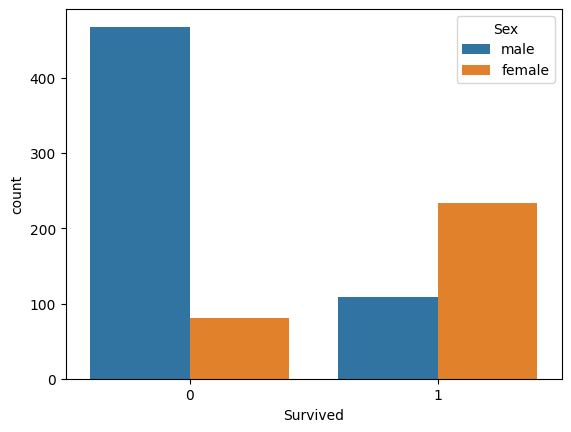

In [6]:
import seaborn as sns
sns.countplot(x='Survived', hue='Sex', data=train)

Step 5: Feature Engineering

In [7]:
train['FamilySize'] = train['SibSp'] + train['Parch']

Step 6: **Convert text to numbers.**
Machine learning don't understand text but data.

In [8]:
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})

Step 7: **Select Features**

In [9]:
features = ['Pclass', 'Sex', 'Age', 'Fare']

X = train[features]
y = train['Survived']

Step 8: Build a machine learning model; for example: **Logistic Regression** 

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X, y)

LogisticRegression()

Step 9: **Prediction**

In [11]:
# 1. Handle missing values in Test set
# Use the same logic as train set
test['Age'] = test['Age'].fillna(test['Age'].median())
test['Fare'] = test['Fare'].fillna(test['Fare'].median())

# 2. Make sure Categorical data is also encoded in Test set
# If you used map for Sex in train, do it for test too
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})



In [12]:
predictions = model.predict(test[features])

Step 10: **Evaluation Metrics**

The model performance was evaluated using:

1. *Confusion Matrix*
   - Provides a detailed breakdown of prediction results.
   - Helps visualize true positives, true negatives, false positives, and false negatives.

2. *Accuracy Score*
   - Calculates the proportion of correctly predicted observations over the total observations.


Dataset trained Successfully


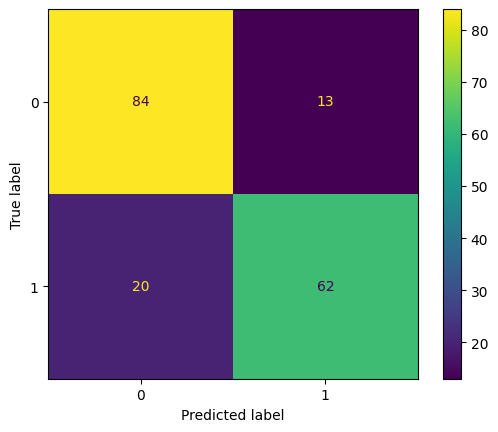

Accuracy: 0.8156424581005587


In [13]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain,ytest = train_test_split(X, y,test_size=0.2)
print('Dataset trained Successfully')
y_pred = model.predict(Xtest)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(ytest, y_pred)
plt.show()


from sklearn.metrics import accuracy_score

accuracy = accuracy_score(ytest, y_pred)

print("Accuracy:", accuracy)

To better understand the effectiveness of the Logistic Regression model,
multiple evaluation metrics are used, including **Accuracy**, **Precision**,
**Recall**, **F1-score**, and **Confusion Matrix**.

Confusion Matrix:
 [[84 13]
 [20 62]]
Precision: 0.8266666666666667
Recall: 0.7560975609756098
F1 Score: 0.7898089171974523

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        97
           1       0.83      0.76      0.79        82

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.81       179



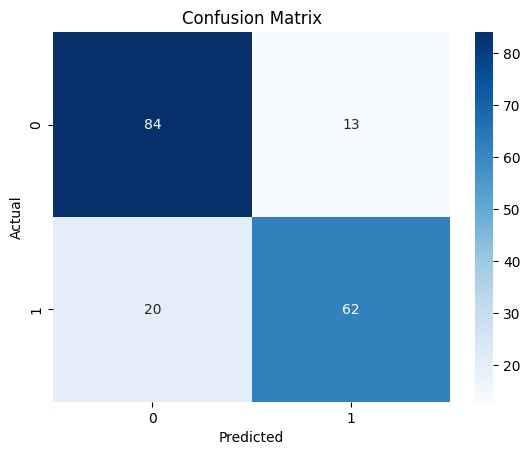

In [14]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred)
print("Confusion Matrix:\n", cm)

# Precision
precision = precision_score(ytest, y_pred)
print("Precision:", precision)

# Recall
recall = recall_score(ytest, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(ytest, y_pred)
print("F1 Score:", f1)

# Full Report
print("\nClassification Report:\n")
print(classification_report(ytest, y_pred))

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Step 11: Create the **submission file**

In [15]:
output = pd.DataFrame({'PassengerId': test.PassengerId, 'Survived': predictions})

output.to_csv('submission.csv', index = False)